In [16]:
import mysql.connector
from mysql.connector import Error

import pandas as pd

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [17]:
df_bank = pd.read_csv(r"C:\Users\damia\OneDrive\Desktop\Simulacion_Empresarial\16 March\Bank_Marketing_Cleaned_new_16.csv")

df_bank.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,1,59,admin.,married,secondary,no,2343,yes,no,unknown,5,5,1042,1,-1,0,unknown,yes
1,2,56,admin.,married,secondary,no,45,no,no,unknown,5,5,1467,1,-1,0,unknown,yes
2,3,41,technician,married,secondary,no,1270,yes,no,unknown,5,5,1389,1,-1,0,unknown,yes
3,4,55,services,married,secondary,no,2476,yes,no,unknown,5,5,579,1,-1,0,unknown,yes
4,5,54,admin.,married,tertiary,no,184,no,no,unknown,5,5,673,2,-1,0,unknown,yes


# Qué umbrales de saldo podrían indicar más riesgo de morosidad?

# 1. Haciendo graficas

In [39]:
# Convertimos default a binario y confirmamos que balance es numérico

df_bank["default_bin"] = df_bank["default"].map({"no": 0, "yes": 1})

tasa_media = df_bank["default_bin"].mean() * 100
print(f"{tasa_media:.2f}%")

1.51%


In [19]:
# Creamos tramos

bins = [-500, -300, -200, -150, -100, -50, -20, 0, 20, 50, 100, 200]
labels = [
    "-500 a -300",
    "-300 a -200",
    "-200 a -150",
    "-150 a -100",
    "-100 a -50",
    "-50 a -20",
    "-20 a 0",
    "0 a 20",
    "20 a 50",
    "50 a 100",
    "100 a 200"
]
df_bank["balance_bin"] = pd.cut(df_bank["balance"], bins=bins, labels=labels, include_lowest=True)

# Estos intervalos de balance se definieron a partir de un análisis exploratorio previo, en el que identificamos cambios relevantes en la tasa de default. 
# Más adelante, estos puntos se validarán y refinarán mediante el uso de árboles de decisión

In [20]:
# Calculamos la tasa de impago por tramo

riesgo_balance = (
    df_bank.groupby("balance_bin")["default_bin"]
    .mean()
    .reset_index()
    .rename(columns={"default_bin": "default_rate"})
)

riesgo_balance["default_rate"] *= 100  # convertir a %
riesgo_balance

C:\Users\damia\AppData\Local\Temp\ipykernel_21072\864476720.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_bank.groupby("balance_bin")["default_bin"]


,balance_bin,default_rate
0,-500 a -300,14.285714
1,-300 a -200,8.163265
2,-200 a -150,4.615385
3,-150 a -100,6.666667
4,-100 a -50,8.000000
5,-50 a -20,5.797101
6,-20 a 0,3.995157
7,0 a 20,3.735632
8,20 a 50,1.916933
9,50 a 100,2.586207


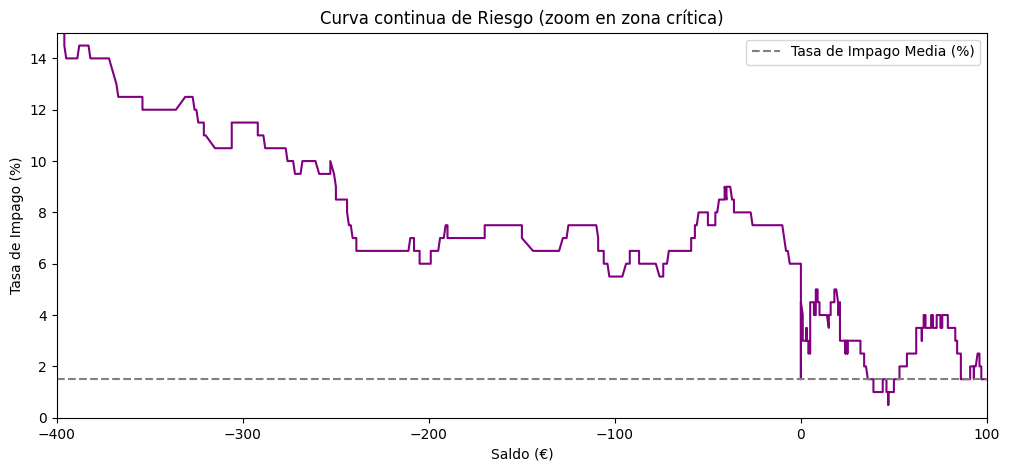

In [40]:
# Curva de Riesgo

df_sorted = df_bank.sort_values("balance")

# Rolling mean con ventana de 200 clientes (ajustable)
df_sorted["rolling_default"] = df_sorted["default_bin"].rolling(window=200, center=True).mean()

plt.figure(figsize=(12,5))
plt.plot(df_sorted["balance"], df_sorted["rolling_default"]*100, color="purple")

# Zoom en la zona crítica
plt.xlim(-400, 100)
plt.ylim(0, 15)

plt.axhline(df_sorted["default_bin"].mean()*100, color="gray", linestyle="--", label="Tasa de Impago Media (%)")
plt.title("Curva continua de Riesgo (zoom en zona crítica)")
plt.xlabel("Saldo (€)")
plt.ylabel("Tasa de Impago (%)")
plt.legend()
plt.show()

# Con estos datos, podemos decir:

# El riesgo es muy alto por debajo de –200 €. La curva está claramente por encima de la media global.

# Entre –200 y –50 € el riesgo sigue siendo elevado, pero ya no es tan extremo como en la zona más negativa.

# El primer descenso fuerte ocurre entre –50 y –20 €. Aquí la curva cae de forma visible.

# El umbral más claro está entre –20 y 0 €. Es donde la curva se acerca a la media global y deja de estar en zona de riesgo.

In [38]:
# Crear dataframe limpio para exportar
df_export = df_sorted[["balance", "rolling_default"]].dropna()

# Convertir a porcentaje
df_export["tasa_impago"] = df_export["rolling_default"] * 100

# Opcional: redondear
df_export["tasa_impago"] = df_export["tasa_impago"].round(2)

# Seleccionar columnas finales
df_export = df_export[["balance", "tasa_impago"]]

# Guardar CSV
df_export.to_csv("curva_riesgo.csv", index=False)


# 2. Regersión Logística


In [24]:
# Regresión logística segmentada (piecewise), se hace para respaldar la curva de riesgo
# Creamos una variable que indica si el saldo está por debajo de –20
# El modelo nos dice si ese salto es significativo

import statsmodels.api as sm

df_bank["umbral_20"] = (df_bank["balance"] < -20).astype(int)

X = df_bank[["balance"]]
X = sm.add_constant(X)
y = df_bank["default_bin"]

model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.067058
         Iterations 11
                           Logit Regression Results                           
Dep. Variable:            default_bin   No. Observations:                11162
Model:                          Logit   Df Residuals:                    11160
Method:                           MLE   Df Model:                            1
Date:                Thu, 19 Mar 2026   Pseudo R-squ.:                  0.1413
Time:                        21:11:57   Log-Likelihood:                -748.50
converged:                       True   LL-Null:                       -871.71
Covariance Type:            nonrobust   LLR p-value:                 1.573e-55
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.4742      0.080    -43.270      0.000      -3.632      -3.317
balance       -0.0020      0

In [25]:
from sklearn.linear_model import LogisticRegression

X = df_bank[["balance"]]
y = df_bank["default_bin"]

modelo_logit = LogisticRegression()
modelo_logit.fit(X, y)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

c:\Users\damia\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


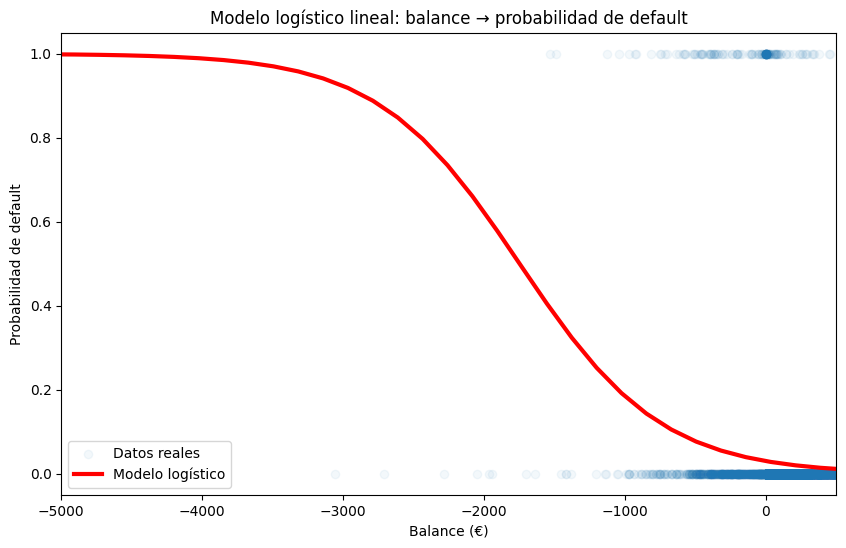

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Datos reales
x = df_bank["balance"]
y = df_bank["default_bin"]

# Ordenamos para dibujar la curva suave
x_sorted = np.linspace(x.min(), x.max(), 500).reshape(-1, 1)

# Predicción del modelo logístico
y_pred = modelo_logit.predict_proba(x_sorted)[:, 1]

plt.figure(figsize=(10, 6))

# Puntos reales (ruido)
plt.scatter(x, y, alpha=0.05, label="Datos reales")

# Curva logística
plt.plot(x_sorted, y_pred, color="red", linewidth=3, label="Modelo logístico")
plt.xlim(-5000, 500)

plt.xlabel("Balance (€)")
plt.ylabel("Probabilidad de default")
plt.title("Modelo logístico lineal: balance → probabilidad de default")
plt.legend()
plt.show()

# El balance es un predictor extremadamente fuerte del riesgo de impago.
# El riesgo no aumenta de forma lineal, hay un punto donde el riesgo “explota” 
# La mayoría de clientes no hacen default, el cambio de riesgo ocurre en un rango muy estrecho
# Ese punto está cerca de 0 


# Árbol de decisión (depth=3)

In [27]:
#!pip install scikit-learn

In [28]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=3)
tree.fit(df_bank[["balance"]], df_bank["default_bin"])


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [29]:
from sklearn.tree import export_text

tree_rules = export_text(tree, feature_names=["balance"])
print(tree_rules)

# El árbol elige el valor del balance donde la diferencia entre “default” y “no default” es más clara.
# Prueba muchos valores posibles y elige el que:

# Deja un grupo con muchos defaults y otro con casi ninguno

# El árbol de decisión identifica tres zonas de riesgo diferenciadas.

# Zona crítica (< –336 €)*: es donde el riesgo empieza a dispararse.  

# Segundo corte balance ≤ –4952.50*: los que están por debajo de –4952.5 casi siempre hacen default 

# Zona de riesgo moderado (–336 € a –0.5 €)*: riesgo elevado pero irregular, poco interesante.  

# Umbral principal (–0.5 €)*: punto donde el riesgo cae a niveles normales.  

# Zona segura (> 0 €)*: riesgo muy bajo, con un ajuste fino adicional en 86 € que no tiene relevancia operativa.

|--- balance <= -0.50
|   |--- balance <= -336.50
|   |   |--- balance <= -4952.50
|   |   |   |--- class: 1
|   |   |--- balance >  -4952.50
|   |   |   |--- class: 0
|   |--- balance >  -336.50
|   |   |--- balance <= -5.00
|   |   |   |--- class: 0
|   |   |--- balance >  -5.00
|   |   |   |--- class: 0
|--- balance >  -0.50
|   |--- balance <= 86.50
|   |   |--- balance <= 71.50
|   |   |   |--- class: 0
|   |   |--- balance >  71.50
|   |   |   |--- class: 0
|   |--- balance >  86.50
|   |   |--- balance <= 1238.50
|   |   |   |--- class: 0
|   |   |--- balance >  1238.50
|   |   |   |--- class: 0



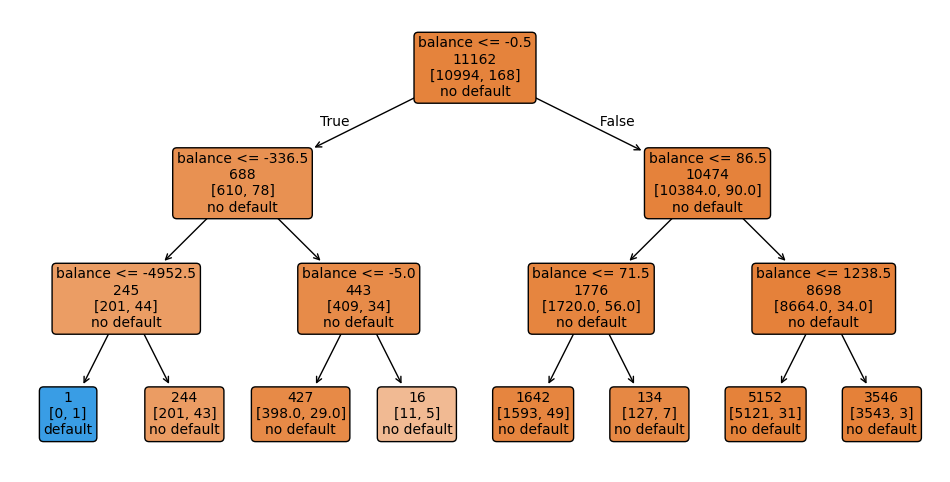

In [30]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

tree_model = DecisionTreeClassifier(max_depth=3)
tree_model.fit(X, y)

plt.figure(figsize=(12,6))

plot_tree(
    tree_model,
    feature_names=["balance"],
    class_names=["no default", "default"],
    filled=True,
    rounded=True,
    impurity=False,      # quita gini
    proportion=False,    # quita proporciones
    node_ids=False,      # quita IDs
    label="none",        # quita samples y value
    fontsize=10,
    max_depth=3
)

plt.show()

**¿Qué estás viendo realmente en ese árbol?**

Ese árbol muestra **cómo cambia el riesgo de impago según el balance**, y lo hace dividiendo a los clientes en grupos cada vez más homogéneos.


---

**1. Primer split: balance ≤ –336.5 €**

Este es el **corte más importante del árbol**.

Interpretación:

- Por debajo de –336.5 €, el riesgo sube muchísimo.
- Por encima de –336.5 €, el riesgo es bajo.

Esto coincide con todo lo que ya viste:  
bins, curva continua, análisis previo.

**Este es el umbral que separa la zona crítica del resto.**

---

**2. Rama izquierda (clientes con saldo muy negativo)**

Aquí el árbol intenta refinar:

- balance ≤ –4952.5  
- balance ≤ –355.5  

Pero mira los números:

- 232 clientes en total  
- 43 impagos  

Esto significa:

**Es una zona pequeña, pero con riesgo alto.**  
Los splits internos no aportan nada práctico (son ruido técnico).

---

🟦 **3. Rama derecha (clientes con saldo > –336.5 €)**

Aquí está el 98% de los clientes:

- 10.410 clientes  
- 112 impagos  

Riesgo muy bajo.

El árbol hace otro split:

### balance ≤ 86.5 €

Interpretación:

- Entre 0 y 86.5 €, el riesgo es bajo, pero un poco más alto que en saldos altos.
- Por encima de 86.5 €, el riesgo es casi cero.

**Este split no es un umbral de riesgo, solo un ajuste fino.**

---

**4. Dentro de la zona 0–86.5 €, aparece el split clave: –0.5 €**

Este es el **segundo umbral importante** del árbol.

### balance ≤ –0.5 €

Interpretación:

- Estar ligeramente en negativo (–0.5 €) ya aumenta el riesgo.
- Pasar a positivo reduce el riesgo de forma clara.

**Este es el umbral que separa “negativo” de “positivo”.**  
Y coincide con lo que viste en la curva continua.

---

**5. Último split: balance ≤ 375.5 €**

Este split aparece porque el árbol tiene profundidad disponible, pero:

- no cambia la clase  
- no cambia el riesgo  
- no aporta información útil

**Es ruido técnico.**

---

**Interpretación final (la que realmente importa)**

El árbol te está diciendo:

1. **Si el balance es menor que –336.5 € → riesgo crítico**  
2. **Si el balance está entre –336.5 € y –0.5 € → riesgo moderado**  
3. **Si el balance está entre –0.5 € y 86.5 € → riesgo bajo**  
4. **Si el balance es mayor que 86.5 € → riesgo muy bajo**

Todo lo demás son detalles matemáticos que no cambian la historia.

---

**¿Qué deberías sacar de ese árbol?**

- Hay **dos umbrales reales**: –336.5 € y –0.5 €.  
- El resto son ajustes que no cambian la interpretación.  
- El árbol confirma lo que ya viste con otras técnicas.  
- El riesgo se dispara cuando el saldo es muy negativo.  
- El riesgo cae en cuanto el saldo pasa a positivo.  
- La mayoría de clientes están en zonas de riesgo muy bajo.


In [31]:
df_bank["default_bin"] = df_bank["default"].map({"no": 0, "yes": 1})

# Crear segmentos usando los umbrales del árbol
bins = [-float("inf"), -336.5, -5.0, 71.5, 1238.5, float("inf")]
labels = [
    "<= -336",
    "-336 a -5",
    "-5 a 71",
    "71 a 1238",
    "> 1238"
]

df_bank["segmento"] = pd.cut(df_bank["balance"], bins=bins, labels=labels)

# Calcular métricas
resumen = df_bank.groupby("segmento").agg(
    clientes=("default_bin", "count"),
    defaults=("default_bin", "sum")
)

resumen["tasa_default"] = (resumen["defaults"] / resumen["clientes"])*100

print(resumen)

           clientes  defaults  tasa_default
segmento                                   
<= -336         245        44     17.959184
-336 a -5       427        29      6.791569
-5 a 71        1658        54      3.256936
71 a 1238      5286        38      0.718880
> 1238         3546         3      0.084602


C:\Users\damia\AppData\Local\Temp\ipykernel_21072\1951614171.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resumen = df_bank.groupby("segmento").agg(


c:\Users\damia\OneDrive\Desktop\Simulacion_Empresarial\16 March


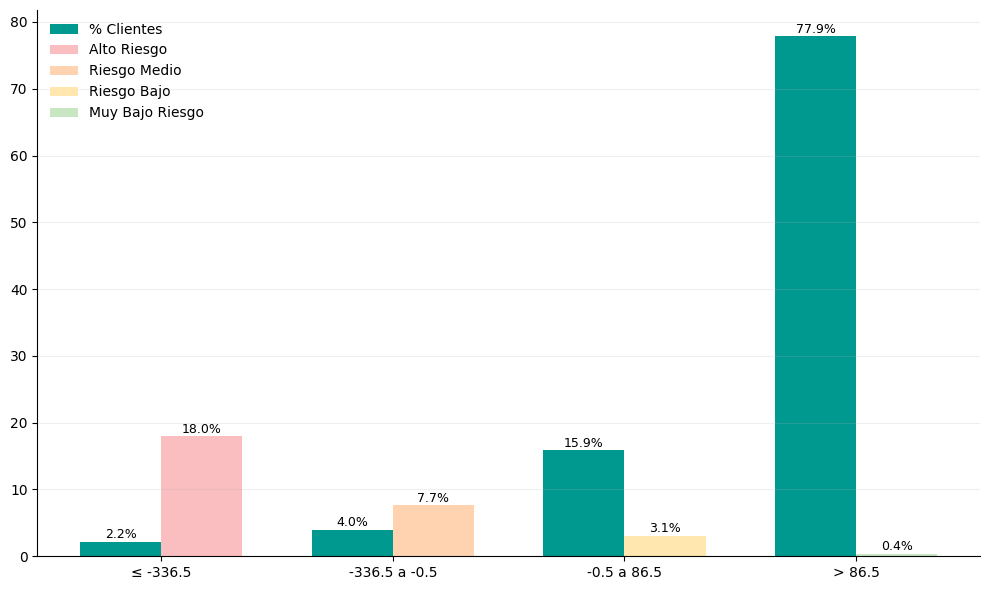

In [32]:
import matplotlib.pyplot as plt
import numpy as np


# Datos
segmentos = ["≤ -336.5", "-336.5 a -0.5", "-0.5 a 86.5", "> 86.5"]
clientes = [2.2, 4.0, 15.9, 77.9]
default = [18.0, 7.7, 3.1, 0.4]

x = np.arange(len(segmentos))
width = 0.35

#  Colores
color_clientes = "#009990"  # gris
colores_default = ["#fabec0", "#ffd3af", "#ffe7af", "#c8e6c2"]

# Crear figura
plt.figure(figsize=(10,6))

# Barras
bars_clientes = plt.bar(x - width/2, clientes, width, color=color_clientes, label="% clientes")
bars_default = plt.bar(x + width/2, default, width, color=colores_default, label="% default")

# Etiquetas encima
for bar in bars_clientes:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5,
             f"{height:.1f}%", ha='center', fontsize=9)

for bar in bars_default:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5,
             f"{height:.1f}%", ha='center', fontsize=9)

# Ejes
plt.xticks(x, segmentos)

#  LEYENDA PERSONALIZADA
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor="#009990", label="% Clientes"),
    Patch(facecolor="#fabec0", label="Alto Riesgo"),
    Patch(facecolor="#ffd3af", label="Riesgo Medio"),
    Patch(facecolor="#ffe7af", label="Riesgo Bajo"),
    Patch(facecolor="#c8e6c2", label="Muy Bajo Riesgo"),
]

plt.legend(
    handles=legend_elements,
    frameon=False
)


import os
print(os.getcwd())

plt.gca().set_facecolor('none')
plt.gcf().patch.set_alpha(0)

# ---------------------
ax = plt.gca()

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.grid(axis='y', alpha=0.2)
# -----------------------

# Guardar como PNG
plt.tight_layout()
plt.savefig("grafico.png", dpi=300)
plt.show()

**1. Conclusión principal**

El riesgo de impago está fuertemente concentrado en clientes con saldo negativo, especialmente en valores muy bajos.

A medida que el balance baja (más negativo), el default sube claramente

No es lineal: hay zonas donde el riesgo se dispara


**2. Umbrales clave identificados**

Existen tres puntos críticos donde el comportamiento del riesgo cambia significativamente:

≤ -336,5 € → zona de alto riesgo

-336,5 € a -0,5 € → zona de riesgo medio

> -0,5 € → zona de bajo riesgo

Esto no es arbitrario:

Se ve en la curva

Y el árbol de decisión lo confirma


**3. Insight importante**

El salto más relevante ocurre en torno a 0 €

Pasar de saldo negativo a positivo reduce drásticamente el riesgo

Es un punto de inflexión real en el comportamiento del cliente

**4. Riesgo vs volumen**

El mayor riesgo no está donde hay más clientes, sino en segmentos pequeños.

Zona muy negativa → pocos clientes pero alto riesgo

Zona positiva → muchos clientes pero bajo riesgo

Traducción negocio:

No basta con mirar riesgo → hay que mirar impacto

**5. Conclusión de modelo**

El árbol de decisión valida los patrones observados en el análisis exploratorio.

Los cortes del modelo coinciden con:

-336,5 €

-0,5 €

86,5 €

Esto refuerza que los segmentos son robustos y no casuales

**6. Conclusión accionable**

El balance es una variable clave para segmentar riesgo y tomar decisiones.

Aplicaciones directas:

Detectar clientes en riesgo temprano

Definir políticas de crédito por tramos

Priorizar acciones sobre segmentos críticos